In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/williamdennis/de-lu-electricity-market/dataset_de_lu.parquet
/kaggle/input/datasets/williamdennis/de-lu-electricity-market/dataset_de_lu.csv


# Load Data

In [2]:
df = pd.read_csv("/kaggle/input/datasets/williamdennis/de-lu-electricity-market/dataset_de_lu.csv",
                parse_dates = True)
df.set_index('timestamp_utc', inplace=True)
df.index = pd.to_datetime(df.index)
df = df.iloc[1:] # has many nan values
df

,price_eur_mwh,gen_biomass_mw,gen_fossil_brown_coal_lignite_mw,gen_fossil_coal_derived_gas_mw,gen_fossil_gas_mw,gen_fossil_hard_coal_mw,gen_fossil_oil_mw,gen_geothermal_mw,gen_hydro_pumped_storage_mw,gen_hydro_pumped_storage_consumption_mw,...,flow_be_net_import_mw,flow_se_4_net_import_mw,ntc_dk_1_export_mw,ntc_dk_1_import_mw,ntc_dk_2_export_mw,ntc_dk_2_import_mw,ntc_nl_export_mw,ntc_nl_import_mw,carbon_price_usd,gas_price_usd
timestamp_utc,,,,,,,,,,,,,,,,,,,,,
2019-01-01 00:00:00+00:00,10.0700,4752.895000,5379.397500,455.600000,2975.385000,2404.260000,481.097500,21.53000,62.697500,1410.462500,...,-35.512500,-1.600000,1500.0,900.0,600.0,585.0,NaN,NaN,NaN,NaN
2019-01-01 01:00:00+00:00,-4.0800,4709.940000,5341.015000,469.675000,2728.095000,2228.450000,483.900000,21.46500,150.640000,2476.680000,...,-24.207500,-68.300000,1500.0,900.0,600.0,585.0,NaN,NaN,NaN,NaN
2019-01-01 02:00:00+00:00,-9.9100,4685.170000,5270.422500,501.725000,2660.767500,2356.940000,486.790000,21.35250,41.420000,3284.582500,...,-64.977500,-65.600000,1500.0,900.0,600.0,585.0,NaN,NaN,NaN,NaN
2019-01-01 03:00:00+00:00,-7.4100,4696.860000,5178.872500,520.175000,2713.735000,2308.582500,490.902500,21.08500,3.537500,3715.637500,...,-88.062500,-65.600000,1500.0,900.0,600.0,585.0,NaN,NaN,NaN,NaN
2019-01-01 04:00:00+00:00,-12.5500,4693.612500,5076.632500,494.200000,2727.865000,2311.175000,491.065000,20.50750,2.107500,4797.715000,...,-88.035000,-65.600000,1500.0,900.0,600.0,585.0,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-31 19:00:00+00:00,86.8025,4546.270511,5903.771268,582.746668,8405.938673,4075.665968,397.696000,33.13594,181.754700,401.981575,...,-793.934148,1.679887,2500.0,2500.0,NaN,NaN,1081.0,1081.0,NaN,NaN
2025-12-31 20:00:00+00:00,79.7975,4418.475318,5095.601188,599.359165,8328.708478,4392.124212,397.699333,33.24885,30.120875,1241.120775,...,-901.271635,-29.970750,2500.0,2500.0,NaN,NaN,1081.0,1081.0,NaN,NaN
2025-12-31 21:00:00+00:00,81.3900,4323.811722,4983.325388,584.670003,8392.809152,4908.133048,397.762668,33.73147,341.027250,501.146300,...,-926.127465,212.819206,2500.0,2500.0,NaN,NaN,1081.0,1081.0,NaN,NaN


# Data Health Check

1 	 gen_hydro_water_reservoir_mw
42 	 load_forecast_mw
1 	 flow_fr_export_mw
1 	 flow_fr_import_mw
1 	 flow_fr_net_import_mw
16102 	 ntc_dk_2_export_mw
16102 	 ntc_dk_2_import_mw
14134 	 ntc_nl_export_mw
14134 	 ntc_nl_import_mw
500 	 carbon_price_usd
476 	 gas_price_usd


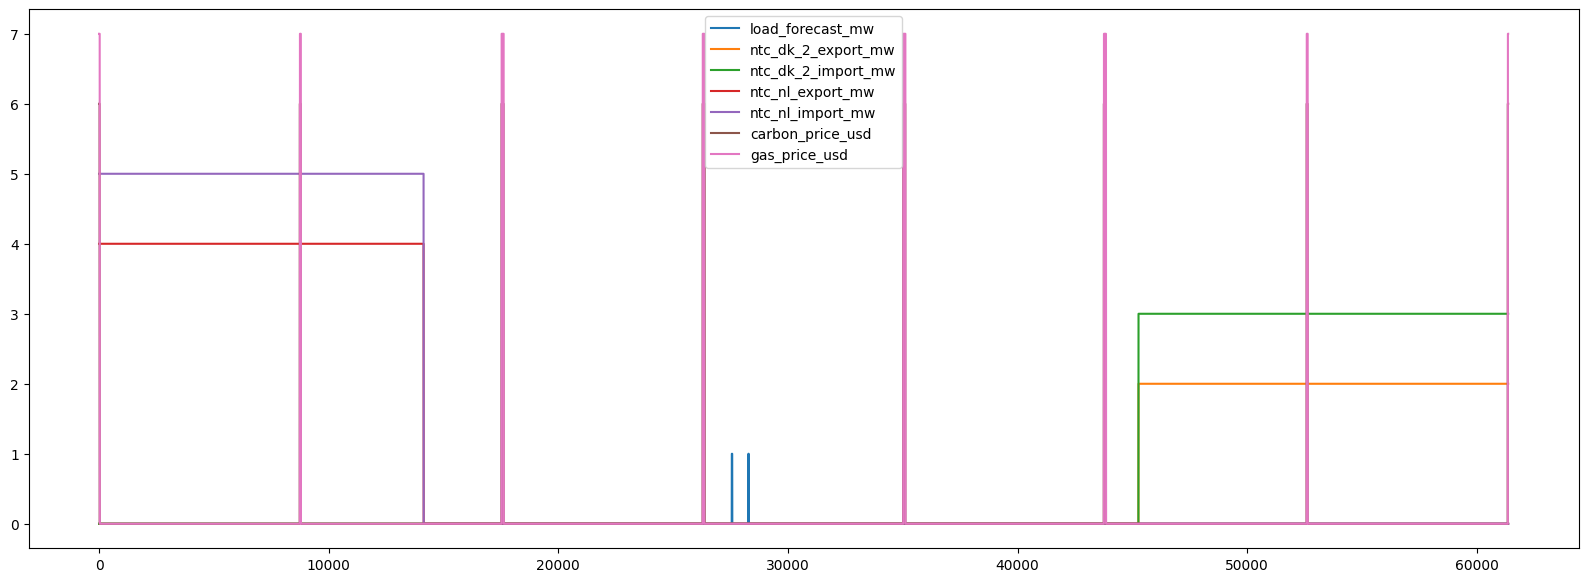

In [3]:
# identify and fix single na values

import matplotlib.pyplot as plt

plt.figure(figsize = (20,7))
i = 1
for column, num_na in df.isna().sum().items():
    if num_na > 0:
        print(num_na, "\t", column)
        if num_na == 1:
            df[column] = df[column].ffill()
        else:
            plt.plot(df[column].isna().values * i, label = column)
            i += 1

plt.legend()
plt.show()

# Nan Value Fixing

42 	 load_forecast_mw


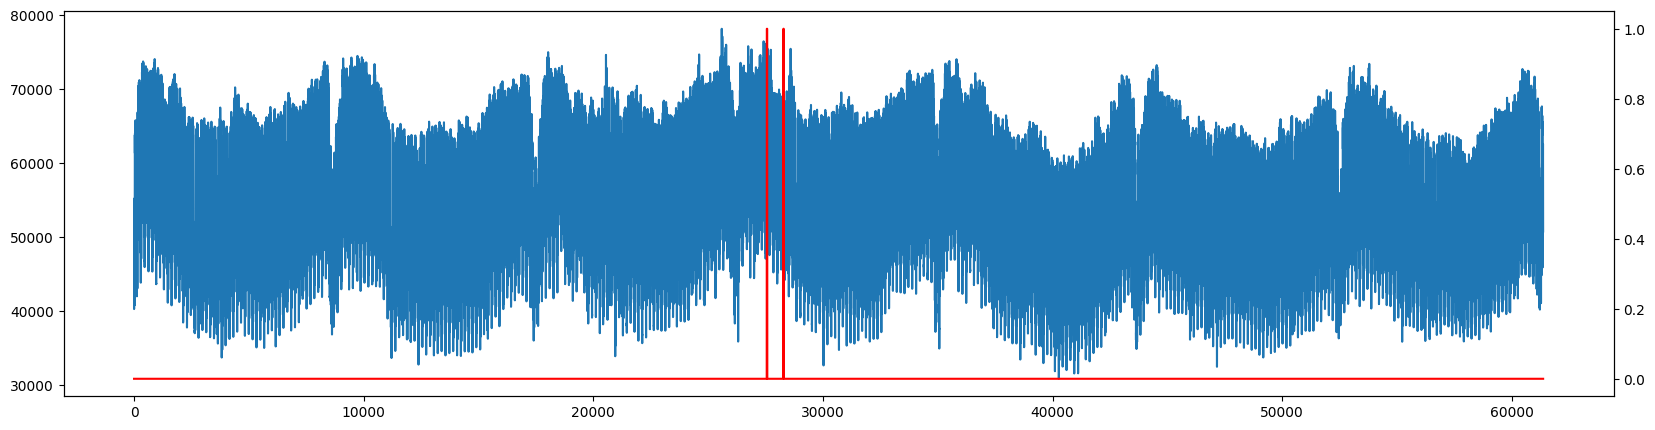

500 	 carbon_price_usd


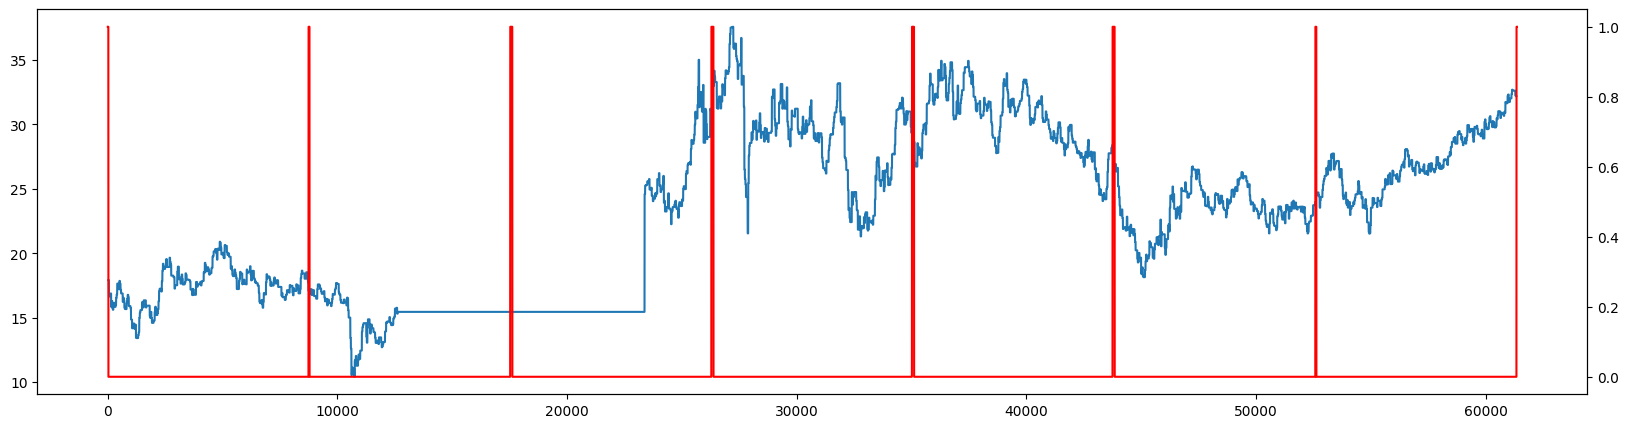

476 	 gas_price_usd


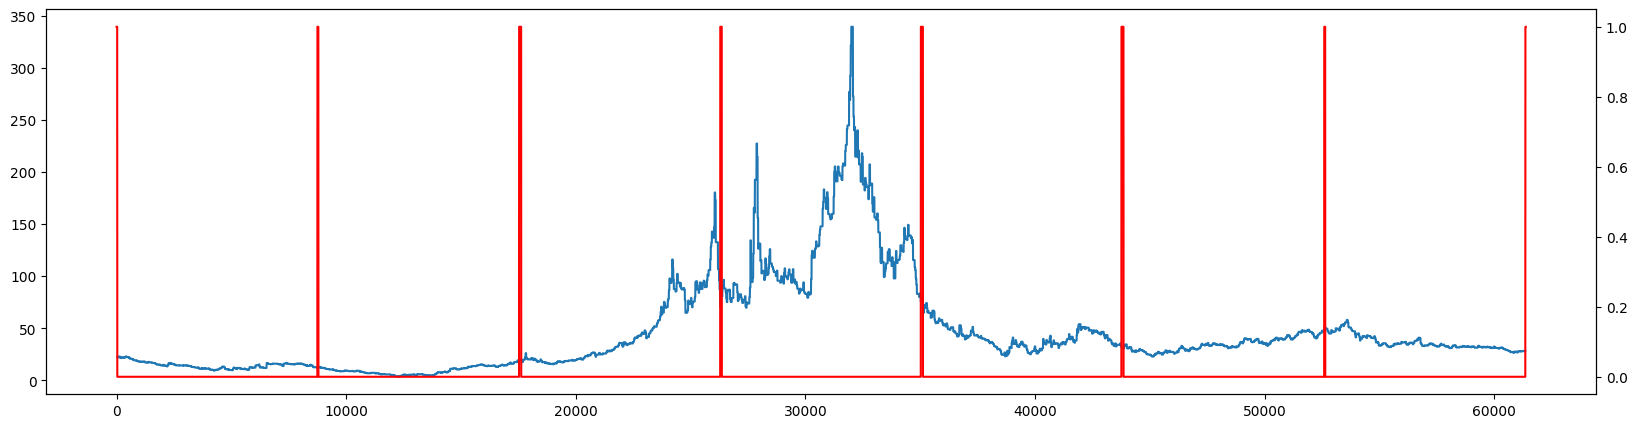

In [4]:
# set interconnector values to 0

interconnectors_to_zero = [
    "ntc_dk_2_export_mw",
    "ntc_dk_2_import_mw",
    "ntc_nl_export_mw",
    "ntc_nl_import_mw"
]

for column in interconnectors_to_zero:
    df[column] = df[column].fillna(0)

i = 1
for column, num_na in df.isna().sum().items():
    if num_na > 0:
        print(num_na, "\t", column)

        plt.figure(figsize = (20,5))
        plt.plot(df[column].values)
        plt.twinx()
        plt.plot(df[column].isna().values, c = "r")
        plt.show()

42 	 load_forecast_mw


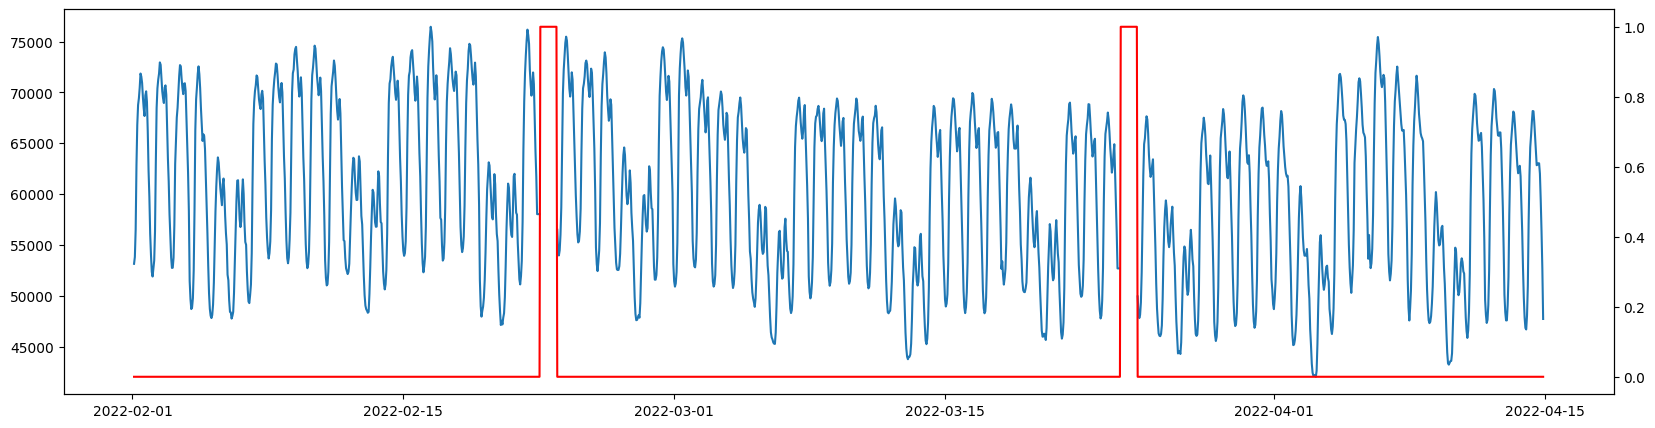

In [5]:
# fill gas and carbon prices with linear interp / bfill

for column in ["carbon_price_usd", "gas_price_usd"]:
    df[column] = df[column].interpolate(method = "linear")
    df[column] = df[column].bfill()

for column, num_na in df.isna().sum().items():
    if num_na > 0:
        print(num_na, "\t", column)

mask = df[df["load_forecast_mw"].isna()]
start = mask.index[0] - pd.Timedelta("3w")
end = mask.index[-1] + pd.Timedelta("3w")
sliced_load_forecast = df[start:end]["load_forecast_mw"]

plt.figure(figsize = (20,5))
plt.plot(sliced_load_forecast)
plt.twinx()
plt.plot(sliced_load_forecast.isna(), c = "r")
plt.show()

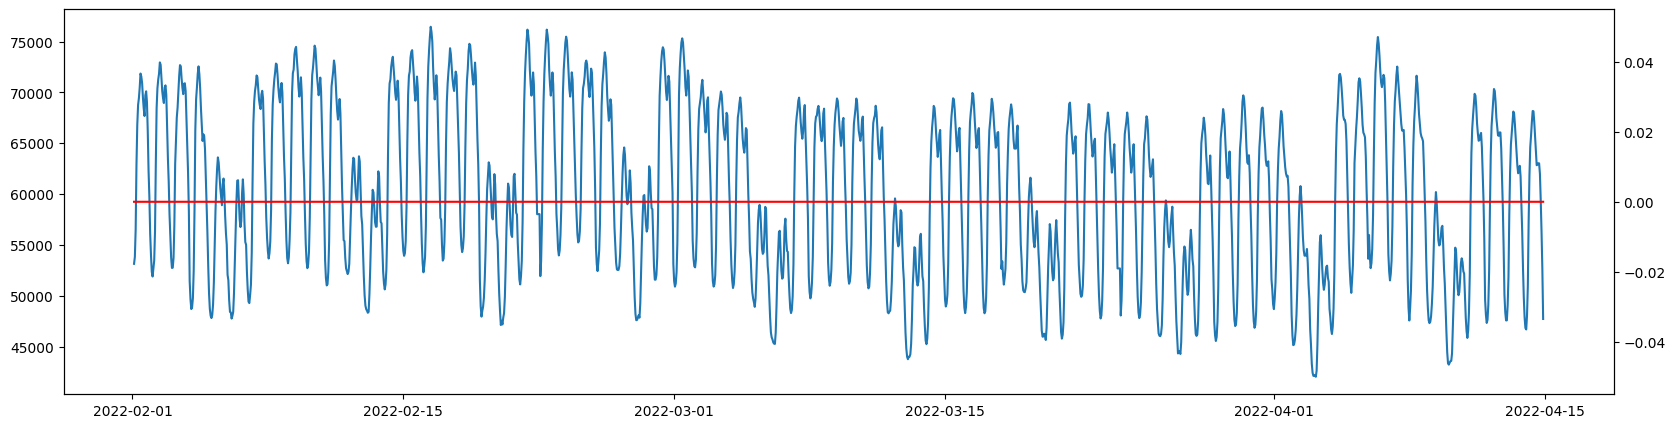

In [6]:
# fill load_forecast_mw using ffill of last 24 hr price

for i in mask.index:
    df.loc[i, "load_forecast_mw"] = df.loc[i - pd.Timedelta("1d"), "load_forecast_mw"]

plt.figure(figsize = (20,5))
plt.plot(sliced_load_forecast)
plt.twinx()
plt.plot(sliced_load_forecast.isna(), c = "r")
plt.show()

for column, num_na in df.isna().sum().items():
    if num_na > 0:
        print(num_na, "\t", column)

# Exploratory Analysis

In [7]:
# TODO

# Model Preparataion

Due to the market structure of the day-ahead market in DEU. We must predict prices 24 hours in advance. 

In [8]:
# Due to the market structure of the day-ahead market in DEU. 
# We must predict prices 24 hours in advance.

# We also have a number of features that are predictions (forecast)

Y_df = df[["price_eur_mwh"]].shift(-24).dropna()
X_df = df.copy()

forecasted_columns = [col for col in list(X_df) if "forecast" in col]
print(f"shifting {forecasted_columns} by -24 hours")
X_df[forecasted_columns] = X_df[forecasted_columns].shift(-24)

X_df = df.loc[Y_df.index, :]

# Split train/test by year
train_mask = X_df.index.year < 2025
test_mask  = X_df.index.year == 2025

X_train = X_df.loc[train_mask]
X_test  = X_df.loc[test_mask]

y_train = Y_df.loc[train_mask]
y_test  = Y_df.loc[test_mask]

print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)

X_train = X_train.values
X_test  = X_test.values
y_train = y_train.values.ravel()
y_test  = y_test.values.ravel()

shifting ['load_forecast_mw', 'forecast_solar_mw', 'forecast_wind_offshore_mw', 'forecast_wind_onshore_mw'] by -24 hours
(52608, 75) (8736, 75)
(52608, 1) (8736, 1)


# Baseline Model 1: Yesterday's price persists

In [9]:
prediction_1 = X_test[:,0]

def calculate_RMSE(arr1, arr2):
    assert arr1.shape == arr2.shape, f"{arr1.shape}, {arr2.shape}"
    return float(np.sqrt(((arr1 - arr2) ** 2).mean()))

rmse = calculate_RMSE(y_test, prediction_1)
print(rmse)

40.352029937431894


# Baseline Model 2: Linear Regressor

In [10]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)
prediction_2 = model.predict(X_test)

rmse = calculate_RMSE(y_test, prediction_2)
print(rmse)

34.90688802694678


# Baseline Model 3: Other Fast Baseline Models

In [11]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, SGDRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor

models = {
    "Ridge": Ridge(),
    "Lasso": Lasso(),
    "ElasticNet": ElasticNet(),
    "KNN_4": KNeighborsRegressor(n_neighbors=4),
    "KNN_20": KNeighborsRegressor(n_neighbors=20),
    "DecisionTree": DecisionTreeRegressor(
        criterion="squared_error",
        min_impurity_decrease=0.001
    ),
}

import numpy as np
results = []

for name, model in models.items():

    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    rmse = np.sqrt(((y_test - pred) ** 2).mean())
    results.append((name, rmse))
    print(f"{name}: RMSE = {rmse:.3f}")

Ridge: RMSE = 34.907


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.800e+06, tolerance: 5.158e+04
  model = cd_fast.enet_coordinate_descent(


Lasso: RMSE = 34.916


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.042e+07, tolerance: 5.158e+04
  model = cd_fast.enet_coordinate_descent(


ElasticNet: RMSE = 34.898
KNN_4: RMSE = 57.364
KNN_20: RMSE = 43.684
DecisionTree: RMSE = 54.433
